In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import sys
from rich.progress import track
from scipy.integrate import quad
from scipy.optimize import fsolve
from tqdm.notebook import tqdm

In [2]:
sys.path.append("../")
from pynilc import NeedletTransform

In [3]:
freq = [28, 35, 45, 65, 75, 95, 115, 130, 145, 165, 190, 220, 275, 340, 390, 450, 520, 600, 700, 850][::3]
fwhm = [39.9, 31.9, 24.8, 17.1, 14.91, 11.7, 9.72, 8.59, 7.7, 6.77, 5.88, 5.08, 4.06, 3.28, 3.26, 2.86, 2.48, 1.86, 1.59, 1.31][::3]
nlpp = [16.5, 13.3, 11.9, 8.9, 5.1, 4.6, 3.1, 3.1, 3.4, 2.5, 2.8, 3.3, 6.3, 11.4, 21.9, 43.4, 102.0, 288.0, 1122.0, 9550.0][::3]
nltt = np.array(nlpp)/np.sqrt(2)
nside = 1024
npix = hp.nside2npix(nside)

In [31]:
bandcenters = np.arange(0,4000,100)#np.array([0, 100, 200, 350, 500, 750, 1000, 1350, 1700, 2000])
needlet_bands = NeedletTransform.CosineNeedlet(bandcenters)

In [32]:
len(freq)

7

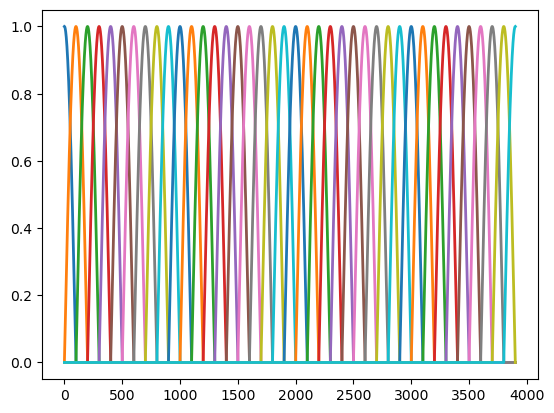

In [33]:
nbands = needlet_bands.shape[0]
nlmax = needlet_bands.shape[1] - 1
for i in range(nbands):
     plt.plot(np.arange(nlmax + 1), needlet_bands[i, :], label=f'Band {i + 1}', linewidth=2)

In [8]:
maps = []
for i in tqdm(range(len(freq)), desc="Reading maps"):
    fname = f"../../simulations/totalsky_{str(freq[i]).replace('.','p')}ghz.fits"
    maps.append(hp.read_map(fname, field=(0,1,2)))

Reading maps:   0%|          | 0/7 [00:00<?, ?it/s]

In [9]:
tebmaps = []
cell_lmax = 3 * nside - 1
for i in tqdm(range(len(freq)), desc="Transforming maps"):
    eb = hp.map2alm_spin(maps[i][1:],2)
    e = hp.alm2map(eb[0], nside)
    b = hp.alm2map(eb[1], nside)
    tebmaps.append([maps[i][0], e, b])

Transforming maps:   0%|          | 0/7 [00:00<?, ?it/s]

In [10]:
def compute_beam_ratio(original_beam_fwhm, target_beam_fwhm, nlmax):
    original_beam = hp.gauss_beam(np.radians(original_beam_fwhm / 60.0), lmax=nlmax,pol=False)
    target_beam = hp.gauss_beam(np.radians(target_beam_fwhm / 60.0), lmax=nlmax, pol=False)
    beam_ratio_cutoff = 10
    beam_ratio = np.zeros_like(target_beam)
    which_indices = original_beam > 0
    beam_ratio[which_indices] = target_beam[which_indices] / original_beam[which_indices]
    target_nlmax = np.where(beam_ratio < beam_ratio_cutoff)[0][-1] 
    target_beam_ratio = beam_ratio[:target_nlmax + 1]
    return target_beam_ratio, target_nlmax

In [11]:
def change_beam_resolution(original_map, beam_ratio, target_nlmax):
    original_nside = hp.get_nside(original_map)
    original_alm = hp.map2alm(original_map, lmax=target_nlmax)
    target_alm = hp.almxfl(original_alm, beam_ratio)
    target_map = hp.alm2map(target_alm, nside=original_nside, lmax=target_nlmax)
    return target_map

In [12]:
target_beam_fwhm_arcmin = 10
target_beam_nlmax = 2000

In [13]:
tebmaps_deconv = []
beam_ratio_list = []
target_nlmax_list = []
for i in tqdm(range(len(freq)), desc="Smoothing maps"):
    beam_ratio, target_nlmax = compute_beam_ratio(fwhm[i], target_beam_fwhm_arcmin, target_beam_nlmax)
    tebmapsi = []
    for j in range(3):
        tebmapsi.append(change_beam_resolution(tebmaps[i][j], beam_ratio, target_nlmax))
    beam_ratio_list.append(beam_ratio)
    target_nlmax_list.append(target_nlmax)
    tebmaps_deconv.append(tebmapsi)

Smoothing maps:   0%|          | 0/7 [00:00<?, ?it/s]

In [14]:
def needlet_analysis(input_map, needlet_bands):
    needlet_coeffs = []
    nbands = needlet_bands.shape[0]
    for b in tqdm(range(nbands), desc="Analyzing needlet bands",position=1,leave=None):
        needlet_nlmax = np.max(np.where(needlet_bands[b, :] > 0))  
        needlet_nside = int(2 ** np.ceil(np.log2(needlet_nlmax / 2))) 
        alm = hp.map2alm(input_map, lmax=needlet_nlmax)
        needlet_alm = hp.almxfl(alm, needlet_bands[b, :needlet_nlmax + 1])
        needlet_map = hp.alm2map(needlet_alm, nside=needlet_nside)
        needlet_coeffs.append({"nside": needlet_nside, "nlmax": needlet_nlmax, "map": needlet_map})  
    return needlet_coeffs


def needlet_synthesis(needlet_coefficients, needlet_bands):
    nbands = needlet_bands.shape[0]
    nlmax = needlet_bands.shape[1] - 1
    output_alm = np.zeros(hp.Alm.getsize(nlmax), dtype=np.complex128)
    l, m = hp.Alm.getlm(nlmax)

    for b in tqdm(range(nbands), desc="Synthesizing needlet bands",position=1,leave=None):
        needlet_nlmax = needlet_coefficients[b]["nlmax"]
        needlet_map = needlet_coefficients[b]["map"]
        needlet_alm = hp.map2alm(needlet_map, lmax=needlet_nlmax)
        needlet_alm = hp.almxfl(needlet_alm, needlet_bands[b, :needlet_nlmax+1])
        whl = np.where(l <= needlet_nlmax)
        output_alm[whl] = output_alm[whl] + needlet_alm
    nside = max([coeff["nside"] for coeff in needlet_coefficients])
    output_map = hp.alm2map(output_alm, nside=nside)
    return output_map

In [15]:
needlets = []
for i in tqdm(range(len(freq)), desc="Needlet transform",position=0):
    target_nlmax = target_nlmax_list[i]
    which_bands = np.where(np.array(bandcenters) <= target_nlmax)[0]
    use_nlmax = np.max(np.array(bandcenters)[which_bands])
    needlet_i = []
    for j in range(3):
        component_coeffs = needlet_analysis(tebmaps_deconv[i][j], needlet_bands[which_bands, :use_nlmax + 1])
        needlet_i_b = []
        for b, coeff in enumerate(component_coeffs):
            needlet_i_b.append(coeff["map"])
        needlet_i.append(needlet_i_b)
    needlets.append(needlet_i)

Needlet transform:   0%|          | 0/7 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/4 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/4 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/4 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/7 [00:00<?, ?it/s]

...

Analyzing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

Analyzing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

In [16]:
def covariance_fwhm(required_num_modes, needlet_bands):
    nlmax = needlet_bands.shape[1] - 1
    l = np.arange(nlmax + 1)
    fwhm_results = []
    for b in range(needlet_bands.shape[0]):
        needlet_band = needlet_bands[b, :]
        total_num_modes = np.sum((2 * l + 1) * (needlet_band)**2)
        def gaussian_integrand(theta, sigma):
            return np.exp(-theta**2 / (2 * sigma**2)) * np.sin(theta)
        def effective_num_modes(fwhm):
            sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
            effective_area_fraction, _ = quad(gaussian_integrand, 0, np.pi, args=(sigma,))
            return (total_num_modes / 2) * effective_area_fraction

        def fwhm_equation(fwhm):
            return effective_num_modes(fwhm) - required_num_modes
        fwhm_guess = 0.5*np.pi 
        fwhm_solution = fsolve(fwhm_equation, fwhm_guess)
        fwhm_results.append(fwhm_solution[0])
    return fwhm_results

In [17]:
required_num_modes = 1000 
cov_fwhm_bands = covariance_fwhm(required_num_modes, needlet_bands)
calibration = np.ones(len(freq))

In [18]:
weights = []

In [24]:
recovered_map = []

In [25]:
for b in tqdm(range(nbands), desc='Computing needlet weights for each band',position=0):
    cov_fwhm = cov_fwhm_bands[b]
    cov_nlmax = np.max(np.where(needlet_bands[b, :] > 0))
    recovered_map_b = []
    for j in tqdm(range(3), desc='CMB fields',position=1,leave=None):
        which_index = [f for f, target_nlmax in enumerate(target_nlmax_list) if target_nlmax >= cov_nlmax]
        cov_map = []
        for f in tqdm(which_index, desc='Frequency bands',position=2,leave=None):
            frequency_f = freq[f]
            needlet_map_f = needlets[f][j][b]
            cov_map_fxf = hp.sphtfunc.smoothing(needlet_map_f * needlet_map_f, fwhm=cov_fwhm, lmax=cov_nlmax)
            cov_map.append(cov_map_fxf)

            for g in which_index:
                if g > f:
                    frequency_g = freq[g]
                    needlet_map_g = needlets[g][j][b]
                    cov_map_fxg = hp.sphtfunc.smoothing(needlet_map_f * needlet_map_g, fwhm=cov_fwhm, lmax=cov_nlmax)
                    cov_map.append(cov_map_fxg)

        cov_map = np.array(cov_map)
        cov_npix = cov_map.shape[1]
        nindex = len(which_index)
        weight_map = np.zeros((nindex, cov_npix))
        for pix in tqdm(range(cov_npix), desc= "Covariance matrix inversion",position=3,leave=None):
            C = np.zeros((nindex, nindex))
            count = 0
            for fi, f in enumerate(which_index):
                C[fi, fi] = cov_map[count, pix]
                count += 1
                for gi, g in enumerate(which_index):
                    if g > f:
                        C[fi, gi] = cov_map[count, pix]
                        C[gi, fi] = C[fi, gi] 
                        count += 1

            try:
                C_inv = np.linalg.inv(C)
            except np.linalg.LinAlgError:
                print(f"Covariance matrix for pixel {pix} is singular.")
                continue

            # Compute weight vector
            numerator = np.dot(C_inv, calibration[:nindex])
            denominator = np.dot(calibration[:nindex].T, numerator)
            weight = numerator / denominator
            weight_map[:, pix] = weight


        weight_npix = len(weight_map[0,:])
        recovered_map_j = np.zeros(weight_npix)
        k = 0
        for fi in tqdm(which_index, desc='Recovering map',position=3,leave=None):
            needlet_map = needlets[fi][j][b]
            recovered_map_j += weight_map[k, :] * needlet_map
            k += 1
        recovered_map_b.append(recovered_map_j)
    recovered_map.append(recovered_map_b)

Computing needlet weights for each band:   0%|          | 0/10 [00:00<?, ?it/s]

CMB fields:   0%|          | 0/3 [00:00<?, ?it/s]

Frequency bands:   0%|          | 0/7 [00:00<?, ?it/s]

Covariance matrix inversion:   0%|          | 0/49152 [00:00<?, ?it/s]

Recovering map:   0%|          | 0/7 [00:00<?, ?it/s]

...

Covariance matrix inversion:   0%|          | 0/12582912 [00:00<?, ?it/s]

Recovering map:   0%|          | 0/5 [00:00<?, ?it/s]

Frequency bands:   0%|          | 0/5 [00:00<?, ?it/s]

Covariance matrix inversion:   0%|          | 0/12582912 [00:00<?, ?it/s]

Recovering map:   0%|          | 0/5 [00:00<?, ?it/s]

In [26]:
cmb_reconstructed = []
for i in tqdm(range(3), desc='Reconstructing CMB',position=0):
    needlet_coefficients = []
    for b in range(nbands):
        recovered_mapi = recovered_map[b][i]
        needlet_nlmax = np.max(np.where(needlet_bands[b, :] > 0))

        needlet_coefficients.append({
            "map": recovered_mapi,
            "nlmax": needlet_nlmax,
            "nside": hp.get_nside(recovered_mapi)
        })

    cmb_reconstructed.append(needlet_synthesis(needlet_coefficients, needlet_bands))


Reconstructing CMB:   0%|          | 0/3 [00:00<?, ?it/s]

Synthesizing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

Synthesizing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

Synthesizing needlet bands:   0%|          | 0/10 [00:00<?, ?it/s]

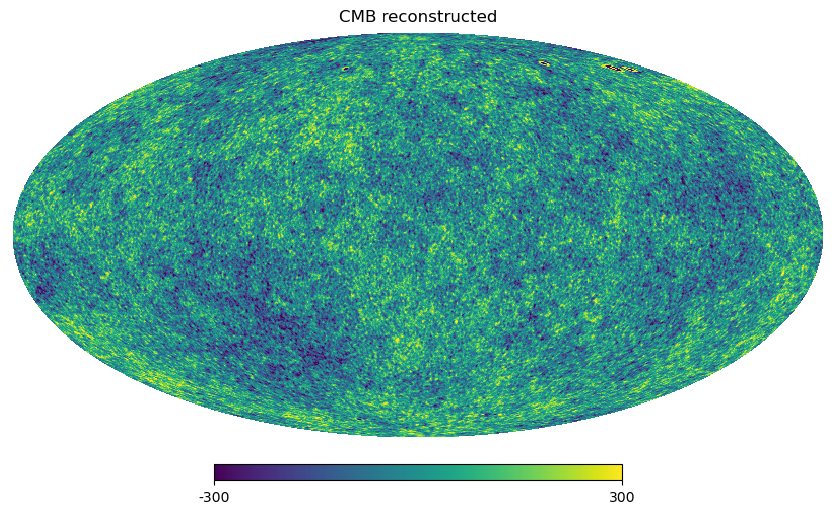

In [27]:
hp.mollview(cmb_reconstructed[0], title='CMB reconstructed', min=-300, max=300)

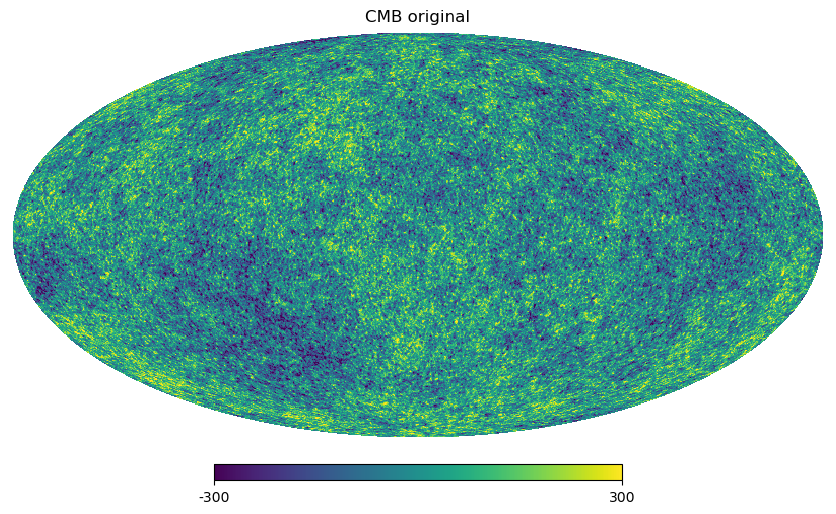

In [63]:
hp.mollview(hp.read_map("../../simulations/camb_cmb.fits", field=0), title='CMB original', min=-300, max=300)